## Part B.1 — Operational setup for batch-1 processing

Before filtering features or samples, we lock the operational dataset used for Part B.  
Following the assignment instructions, downstream processing is restricted to batch 1. We retain the technical classes needed for quality control and contamination assessment (`B`, `SS`, `QC`, `dQC`) together with the biological classes of interest (`Dunn`, `French`, `LMU`).

At this stage, we are not removing samples or features yet. The goal is to define a reproducible input, fix the detection rule, and compare technically reasonable processing views before applying hard filters.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parents[0]
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from load_data import load_task1_inputs
from task1_processing import (
    freeze_partb_inputs,
    compute_detection_inputs,
    compute_qc_vs_dqc_metrics,
    build_transformation_candidates,
    evaluate_transformation_candidates,
    plot_transformation_metric_summary,
    plot_detection_rate_by_class_clear,
)

In [2]:
inputs = load_task1_inputs(project_root=project_root)

data_matrix = inputs["data_matrix"]
feature_metadata = inputs["feature_metadata"]
acquisition_list = inputs["acquisition_list"]

batch1_dm, batch1_acq, batch1_inventory = freeze_partb_inputs(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
)

print("Batch-1 Part B input frozen.")
display(batch1_inventory)
display(batch1_acq.head())
print(batch1_dm.shape)

Batch-1 Part B input frozen.


,class,n_samples
0,B,6
1,SS,1
2,dQC,5
3,QC,11
4,Dunn,27
5,French,26
6,LMU,26


,sample,class,id,order,batch
0,20241106-297-Blank1,B,20241106-297-Blank1,1,1
1,20241106-297-Blank2,B,20241106-297-Blank2,2,1
2,20241106-297-Blank3,B,20241106-297-Blank3,3,1
3,20241106-297-Experimental_Blank,SS,20241106-297-Experimental_Blank,4,1
4,20241106-297-Diluted-QC1,dQC,20241106-297-Diluted-QC1,7,1


(102, 253)


We freeze the Part B input before any thresholding so that all subsequent summaries are computed on the same operational cohort. This avoids mixing diagnostic EDA logic with the actual discovery workflow.

## Part B.2 — Operational detection threshold

For the remaining Part B steps, we define a feature as detected when its intensity is strictly greater than **10**.

This choice is based on the batch-1 EDA: threshold 0 was too permissive because it counted trace blank-level peaks as detections, while threshold 10 preserved strong support in biological and QC samples and reduced the influence of trivial signals.

,class,mean_feature_detection_rate,median_feature_detection_rate,fraction_features_ge_70,fraction_features_ge_90
0,B,0.000000,0.0,0.000000,0.000000
1,SS,0.198413,0.0,0.198413,0.198413
2,dQC,0.986508,1.0,0.980159,0.976190
3,QC,0.992424,1.0,1.000000,0.976190
4,Dunn,0.990447,1.0,0.988095,0.988095
5,French,0.997253,1.0,0.996032,0.992063
6,LMU,0.979548,1.0,0.976190,0.960317


,feature,detection_rate__all,detection_rate__B,detection_rate__SS,detection_rate__dQC,detection_rate__QC,detection_rate__Dunn,detection_rate__French,detection_rate__LMU,detection_rate__biological,...,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-000,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
1,FT-001,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
2,FT-002,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647
3,FT-003,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
4,FT-004,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684
5,FT-005,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,886.632460,886.683375,886.580667,0.026029,609.461289,638.067164,612.067644,606.711878,593.375215,1.287131
6,FT-006,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,887.640372,887.691598,887.593118,0.026411,609.387459,637.957134,612.049137,606.703800,594.204183,1.275731
7,FT-007,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1051.742823,1051.806842,1051.688477,0.029811,753.193130,769.283091,755.954962,750.532679,740.815522,1.293041
8,FT-008,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1050.739664,1050.800543,1050.686090,0.031277,753.457003,778.235971,756.242861,750.762498,739.039389,1.297824
9,FT-009,0.941176,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1049.732664,1049.793639,1049.679381,0.030903,753.593752,783.262112,756.185217,751.129772,737.980813,1.236249


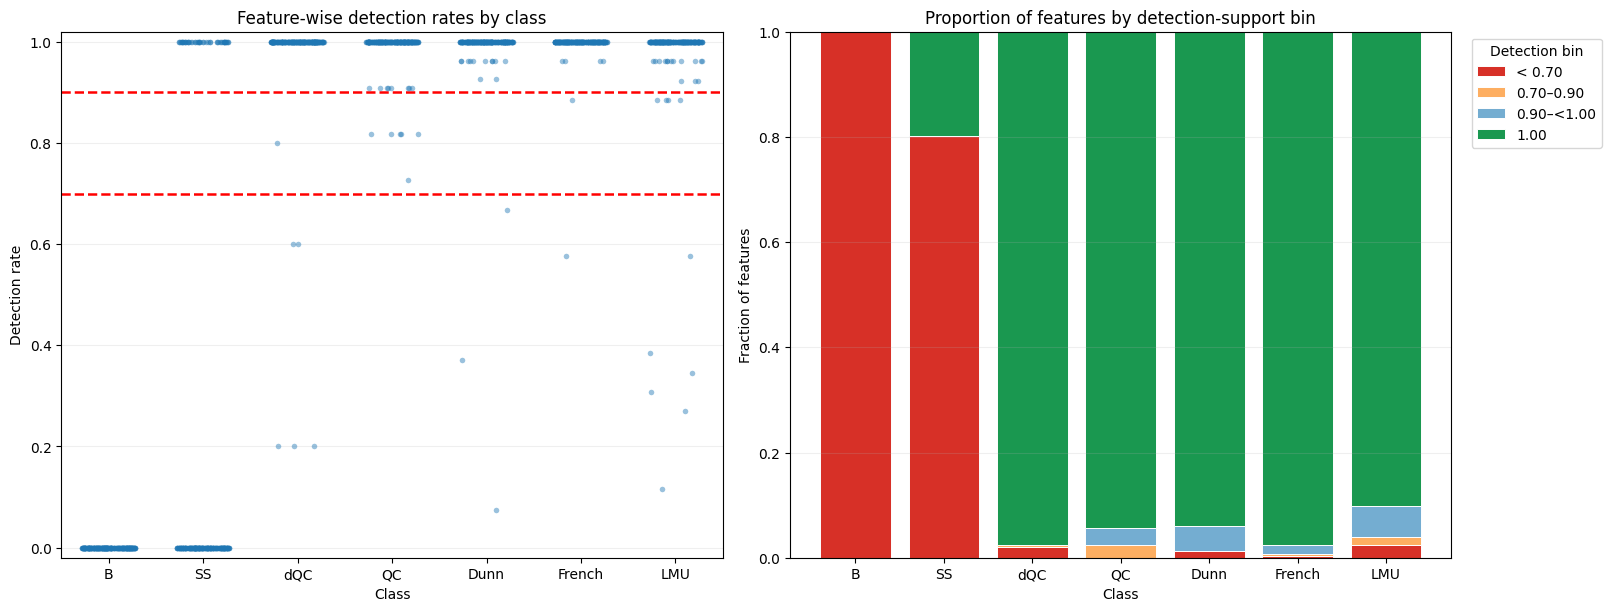

In [3]:
DETECTION_THRESHOLD = 10.0

batch1_feature_detection, batch1_detection_summary = compute_detection_inputs(
    data_matrix=batch1_dm,
    feature_metadata=feature_metadata,
    acquisition_list=batch1_acq,
    detection_threshold=DETECTION_THRESHOLD,
)

display(batch1_detection_summary)
display(batch1_feature_detection.head(10))

fig = plot_detection_rate_by_class_clear(
    batch1_feature_detection,
    classes=("B", "SS", "dQC", "QC", "Dunn", "French", "LMU"),
    thresholds=(0.70, 0.90),
)
plt.show()

Using a positive detection threshold reduces the influence of trace-level peaks, especially in blanks, while maintaining high detection support in the biological classes and QC material. We therefore lock `10` as the operational detection rule for Part B and recompute all downstream detection quantities using this threshold.

## Part B.3 — QC-only stability versus dQC behavior

The diluted QC (`dQC`) is related to QC but not identical to it. Because the main technical acceptance rule is defined on QC, we evaluate QC and dQC separately rather than pooling them.

This allows us to distinguish:
- features that are stable in QC and also stable after dilution,
- features that are stable in QC but unstable in dQC, which may indicate concentration sensitivity rather than general instrument instability.

In [4]:
qc_dqc_metrics, qc_dqc_summary, qc_dqc_ranked = compute_qc_vs_dqc_metrics(
    data_matrix=batch1_dm,
    feature_metadata=feature_metadata,
    acquisition_list=batch1_acq,
    detection_threshold=DETECTION_THRESHOLD,
)

display(qc_dqc_summary)
display(
    qc_dqc_ranked[
        [
            "feature",
            "mz",
            "rt",
            "qc_cv_pct_qc_only",
            "qc_cv_pct_dqc_only",
            "qc_detection_rate_qc_only",
            "qc_detection_rate_dqc_only",
            "potential_concentration_sensitive_flag",
            "cv_gap_dqc_minus_qc",
        ]
    ].head(20)
)

,metric,value
0,n_features_total,252.000000
1,n_features_qc_cv_lt_30_qc_only,193.000000
2,fraction_qc_cv_lt_30_qc_only,0.765873
3,n_features_qc_cv_lt_30_dqc_only,185.000000
4,fraction_qc_cv_lt_30_dqc_only,0.734127
5,n_features_stable_in_both,158.000000
6,n_features_qc_stable_but_dqc_unstable,35.000000
7,median_qc_cv_qc_only,19.775228
8,median_qc_cv_dqc_only,26.533802
9,median_abs_qc_drift_qc_only,0.331818


,feature,mz,rt,qc_cv_pct_qc_only,qc_cv_pct_dqc_only,qc_detection_rate_qc_only,qc_detection_rate_dqc_only,potential_concentration_sensitive_flag,cv_gap_dqc_minus_qc
0,FT-079,1077.209362,1186.459409,29.052572,160.714959,1.0,1.0,True,131.662387
1,FT-192,1068.703772,1157.814720,21.726484,47.482510,1.0,1.0,True,25.756025
2,FT-243,1083.018417,1438.918440,17.689302,42.363863,1.0,1.0,True,24.674561
3,FT-245,1083.021308,1473.133025,23.411946,46.530661,1.0,1.0,True,23.118715
4,FT-202,1033.987006,1386.152000,20.108288,41.071255,1.0,1.0,True,20.962967
5,FT-205,1559.507981,1385.810486,27.098357,47.919919,1.0,1.0,True,20.821563
6,FT-040,1024.685940,1107.617016,13.387821,33.400268,1.0,1.0,True,20.012447
7,FT-004,888.645365,609.255652,20.655925,39.227474,1.0,1.0,True,18.571549
8,FT-006,887.640372,609.387459,19.620209,37.919995,1.0,1.0,True,18.299786
9,FT-002,889.649931,609.099742,20.949984,38.314023,1.0,1.0,True,17.364039


This comparison confirms that QC and dQC should not be merged into a single technical reference class. We therefore use **QC-only** metrics as the primary source for the `<30% CV` stability criterion and retain **dQC** as a secondary check to flag features whose behavior changes substantially under dilution.

## Part B.4 — Compare processing views before sample exclusion

Before removing any samples, we compare several simple processing views to assess whether sample-wise scaling improves technical comparability.

We compare:
- raw intensities,
- `log1p`,
- total-signal scaling followed by `log1p`,
- median-positive scaling followed by `log1p`.

We prefer the processing view that improves QC coherence and reduces run-order structure without collapsing the biological signal.

,method,median_qc_pairwise_corr,min_qc_pairwise_corr,abs_qc_pc1_order_rho,qc_pc1_variance_explained,median_bio_corr_to_class_median,min_bio_corr_to_class_median,qc_total_signal_cv_proxy
0,log1p,0.971314,0.817661,0.327273,0.541328,0.988456,0.846488,3.012029
1,raw,0.971314,0.817661,0.318182,0.574388,0.988432,0.846488,13.004356
2,tic_log1p,0.971314,0.817661,0.163636,0.332032,0.988408,0.846309,1.840976
3,median_log1p,0.971314,0.817661,0.727273,0.449917,0.988266,0.846926,1.409557


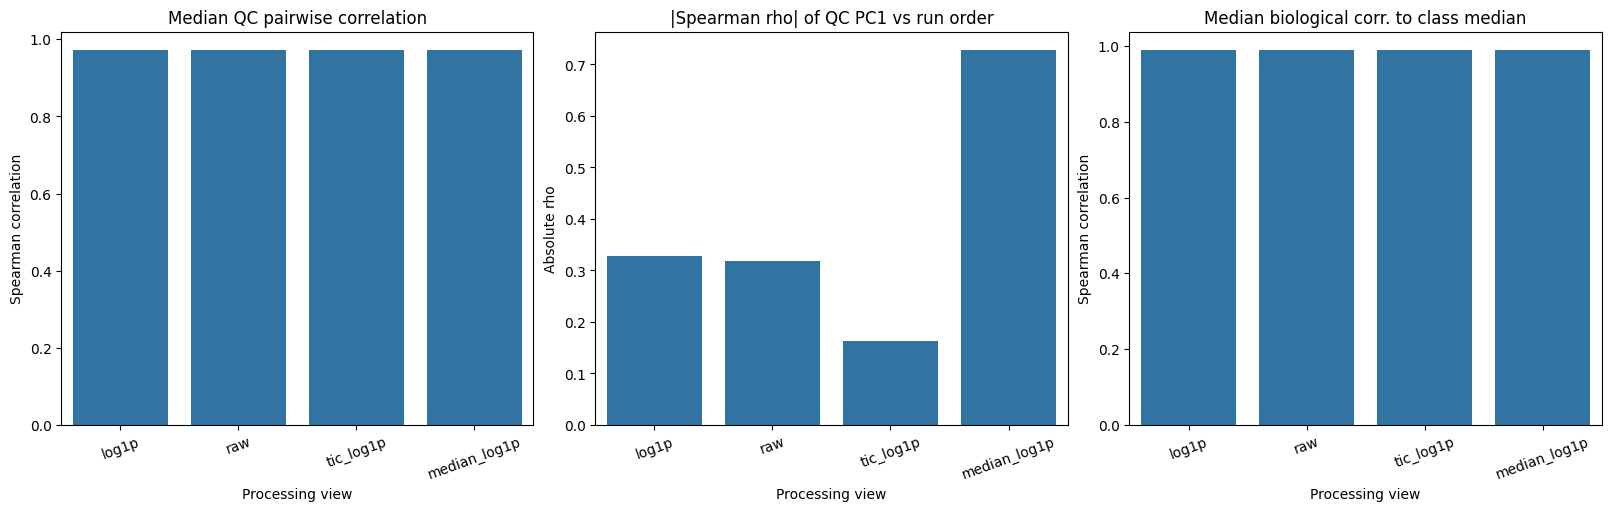

In [5]:
transform_candidates = build_transformation_candidates(batch1_dm)

transform_summary = evaluate_transformation_candidates(
    transformed_candidates=transform_candidates,
    acquisition_list=batch1_acq,
    qc_classes=("QC",),   # primary technical comparison is QC-only
)

display(transform_summary)

fig = plot_transformation_metric_summary(transform_summary)
plt.show()

The processing comparison is used to select an operational representation for downstream filtering. A preferable view should increase QC sample agreement, reduce residual run-order structure in QC space, and preserve class-consistent biological structure. We do not remove samples yet; this step only determines the most defensible processing view for the rest of Part B.

In [6]:
processed_dir = project_root / "data" / "processed" / "task1_partb_setup"
processed_dir.mkdir(parents=True, exist_ok=True)

batch1_acq.to_csv(processed_dir / "batch1_partb_acquisition_list.csv", index=False)
batch1_inventory.to_csv(processed_dir / "batch1_partb_inventory.csv", index=False)
batch1_feature_detection.to_csv(processed_dir / "batch1_partb_feature_detection_threshold10.csv", index=False)
batch1_detection_summary.to_csv(processed_dir / "batch1_partb_detection_summary_threshold10.csv", index=False)
qc_dqc_metrics.to_csv(processed_dir / "batch1_partb_qc_vs_dqc_metrics_threshold10.csv", index=False)
qc_dqc_summary.to_csv(processed_dir / "batch1_partb_qc_vs_dqc_summary_threshold10.csv", index=False)
transform_summary.to_csv(processed_dir / "batch1_partb_transformation_summary.csv", index=False)

print(f"Saved Part B setup artifacts to: {processed_dir}")

Saved Part B setup artifacts to: C:\Users\zakar\OneDrive\Bureau\ml-internship\data\processed\task1_partb_setup


In [7]:
from task1_filtering import (
    build_biological_sample_review,
    plot_biological_sample_review,
    compute_qc_only_technical_biological_metrics,
    build_feature_filter_table,
    plot_feature_filtering_summary,
    assemble_partb_outputs,
)

## Part B.5 — Lock the operational transformed view

The transformation comparison showed that `tic_log1p` provides the best compromise for sample-level comparability. QC pairwise rank correlations were essentially unchanged across the candidate views, so the decisive criteria were residual run-order structure and global QC intensity variability. `tic_log1p` reduced these technical effects most clearly without degrading biological class coherence.

We therefore use `tic_log1p` as the operational transformed view for sample review, PCA-based diagnostics, and the downstream modeling matrix. The raw batch-1 intensities are still retained for feature-level filtering metrics such as detection support, QC CV, and contamination.

In [8]:
SELECTED_TRANSFORM = "tic_log1p"
batch1_dm_transformed = transform_candidates[SELECTED_TRANSFORM]

parta2_dir = project_root / "data" / "processed" / "task1_batch1_operational"

batch1_contamination_metrics = pd.read_csv(parta2_dir / "batch1_contamination_metrics.csv")
batch1_blank_carryover_proxy = pd.read_csv(parta2_dir / "batch1_blank_carryover_proxy.csv")

print("Selected transform:", SELECTED_TRANSFORM)
print("Loaded Part A.2 artifacts from:", parta2_dir)

Selected transform: tic_log1p
Loaded Part A.2 artifacts from: C:\Users\zakar\OneDrive\Bureau\ml-internship\data\processed\task1_batch1_operational


Using the selected `tic_log1p` view, we reviewed biological samples with a multi-criterion scorecard based on total signal, detected feature count, zero fraction, correlation to the class median profile, and PCA distance to the class centroid.

Most samples remained coherent within class. Only 3 biological samples were flagged for exclusion after failing several orthogonal checks, while a small number of additional samples were kept under minor review. This supports a conservative sample-filtering strategy: retain by default, and exclude only when multiple indicators suggest technical failure rather than genuine biology.

## Part B.6 — Biological sample review framework

We now review biological samples using multiple orthogonal diagnostics rather than removing unusual samples based on a single metric. For each biological sample, we track:
- global signal level,
- detected feature count,
- zero fraction,
- correlation to the class median profile,
- PCA distance to the class centroid.

Samples are retained by default. We only mark them for stronger review when several indicators point in the same direction, and we only recommend exclusion when the evidence suggests technical failure rather than genuine biological distinctiveness.

,class,review_tier,n_samples
0,Dunn,keep,24
1,Dunn,minor_review,2
2,Dunn,strong_review,1
3,French,keep,23
4,French,minor_review,3
5,LMU,keep,22
6,LMU,minor_review,2
7,LMU,strong_review,2


,sample,class,order,log10_total_signal_plus1,detected_features,zero_fraction,corr_to_class_median,pca_distance_to_class_centroid,n_review_flags,review_tier,recommend_exclude
17,20241106-297-Dunn-13,Dunn,63,5.839920,243,0.035714,0.846309,32.448280,4,strong_review,True
64,20241106-297-LMU-6,LMU,64,5.890558,239,0.051587,0.851824,29.546899,4,strong_review,True
65,20241106-297-LMU-23,LMU,65,5.843883,240,0.047619,0.884069,15.304382,3,strong_review,True
63,20241106-297-LMU-9,LMU,61,5.802552,244,0.031746,0.883161,15.376666,1,minor_review,False
51,20241106-297-French-23,French,95,5.872199,250,0.007937,0.943163,11.712284,1,minor_review,False
50,20241106-297-French-22,French,93,5.828014,250,0.007937,0.956645,9.042254,1,minor_review,False
42,20241106-297-French-3,French,60,5.897455,251,0.003968,0.956918,7.439734,1,minor_review,False
26,20241106-297-Dunn-27,Dunn,99,5.839721,249,0.011905,0.968897,14.722646,1,minor_review,False
23,20241106-297-Dunn-18,Dunn,85,5.909170,250,0.007937,0.971658,8.472961,1,minor_review,False
68,20241106-297-LMU-21,LMU,71,5.746144,248,0.015873,0.973349,21.478597,1,minor_review,False


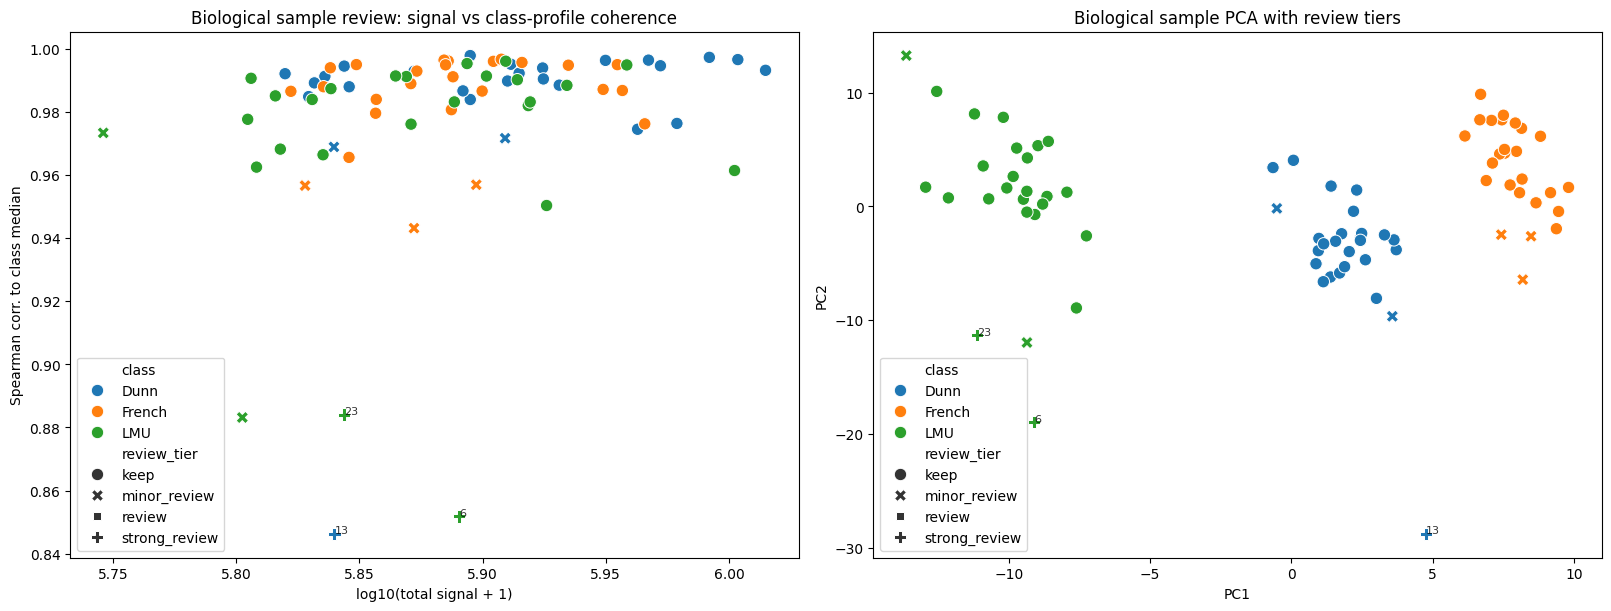

In [9]:
bio_sample_review, bio_sample_review_summary = build_biological_sample_review(
    raw_data_matrix=batch1_dm,
    transformed_data_matrix=batch1_dm_transformed,
    acquisition_list=batch1_acq,
    detection_threshold=DETECTION_THRESHOLD,
)

display(bio_sample_review_summary)
display(
    bio_sample_review[
        [
            "sample",
            "class",
            "order",
            "log10_total_signal_plus1",
            "detected_features",
            "zero_fraction",
            "corr_to_class_median",
            "pca_distance_to_class_centroid",
            "n_review_flags",
            "review_tier",
            "recommend_exclude",
        ]
    ].sort_values(
        ["recommend_exclude", "n_review_flags", "corr_to_class_median"],
        ascending=[False, False, True],
    ).head(20)
)

fig = plot_biological_sample_review(bio_sample_review)
plt.show()

This scorecard is intentionally conservative. The goal is not to purge biologically interesting samples, but to identify cases where several technical indicators fail simultaneously. Samples that are only mildly unusual are retained and simply documented for caution.

## Part B.7 — Feature filtering and prioritization

We now construct the operational feature filter using four components:

1. **Core hard filters** based on the assignment:
   - `m/z > 500`
   - `QC CV < 30%`
   - detection support `>= 70%` in at least one biological class

2. **Contamination veto**:
   strongly blank-dominant features are excluded, but mild blank presence is not treated as sufficient reason for removal.

3. **Carryover annotation**:
   potential blank carryover is tracked as a warning flag rather than an automatic veto.

4. **D-ratio(log)**:
   this is used as a ranking and confidence layer after the main retained set has been defined.

In [10]:
batch1_qc_only_techbio = compute_qc_only_technical_biological_metrics(
    raw_data_matrix=batch1_dm,
    feature_metadata=feature_metadata,
    acquisition_list=batch1_acq,
    detection_threshold=DETECTION_THRESHOLD,
    qc_class="QC",
)

display(batch1_qc_only_techbio.head(10))

,feature,qc_mean_intensity,qc_std_intensity,qc_cv_pct,qc_log_sd,qc_detection_rate,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,...,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-000,1555.658673,143.050123,9.195470,0.093083,1.0,1543.293549,128.640187,8.335432,0.086176,...,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
1,FT-001,2260.709717,201.691409,8.921597,0.092033,1.0,2277.660688,205.769826,9.034262,0.091599,...,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
2,FT-002,1375.062761,288.075434,20.949984,0.244941,1.0,1439.636431,450.079252,31.263397,0.439854,...,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647
3,FT-003,3730.870455,343.031180,9.194401,0.095634,1.0,3754.799419,342.394976,9.118862,0.093142,...,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
4,FT-004,4927.071786,1017.732248,20.655925,0.250068,1.0,4984.858382,1549.463134,31.083393,0.449000,...,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684
5,FT-005,30133.945008,5345.247283,17.738292,0.212125,1.0,30292.076434,8830.420948,29.150927,0.404183,...,886.632460,886.683375,886.580667,0.026029,609.461289,638.067164,612.067644,606.711878,593.375215,1.287131
6,FT-006,14237.665886,2793.459752,19.620209,0.233337,1.0,14353.002814,4482.013536,31.227009,0.430029,...,887.640372,887.691598,887.593118,0.026411,609.387459,637.957134,612.049137,606.703800,594.204183,1.275731
7,FT-007,1808.871231,277.971615,15.367131,0.161713,1.0,1963.180217,294.842873,15.018635,0.151979,...,1051.742823,1051.806842,1051.688477,0.029811,753.193130,769.283091,755.954962,750.532679,740.815522,1.293041
8,FT-008,5947.237608,836.339212,14.062650,0.146877,1.0,6348.454790,900.679786,14.187386,0.142509,...,1050.739664,1050.800543,1050.686090,0.031277,753.457003,778.235971,756.242861,750.762498,739.039389,1.297824
9,FT-009,15570.570638,2137.154805,13.725604,0.145021,1.0,16370.722414,2183.547282,13.338124,0.133395,...,1049.732664,1049.793639,1049.679381,0.030903,753.593752,783.262112,756.185217,751.129772,737.980813,1.236249


,stage,n_features
0,start,252
1,mz>500,248
2,mz>500 & QC_CV<30,197
3,mz>500 & QC_CV<30 & bio_detection>=70_in_any_c...,197
4,main_retained_after_blank_veto,197
5,high_confidence_retained_dratio_log<=1.0,54


,feature,mz,rt,qc_cv_pct,bio_detection_rate_max,blank_detection_rate,blank_to_bio_ratio,blank_dominant_veto,potential_carryover_flag,d_ratio_log,retained_main,retained_high_confidence,exclusion_reason
0,FT-145,1632.042224,1455.244908,15.977542,1.0,0.000000,0.001133,False,False,0.218311,True,True,retained
1,FT-015,1685.172274,962.883034,17.242749,1.0,0.000000,0.000585,False,False,0.222270,True,True,retained
2,FT-174,1210.830470,928.694830,23.971384,1.0,0.000000,0.019915,False,False,0.257408,True,True,retained
3,FT-188,931.123316,1102.187969,29.208426,1.0,0.000000,0.004178,False,False,0.323803,True,True,retained
4,FT-028,1845.267570,1057.465323,24.605374,1.0,0.000000,0.001881,False,False,0.368519,True,True,retained
5,FT-156,1560.001369,1419.237135,18.798516,1.0,0.000000,0.000561,False,False,0.414189,True,True,retained
6,FT-217,1089.028799,1473.438882,22.115486,1.0,0.000000,0.007739,False,False,0.439181,True,True,retained
7,FT-146,1633.038705,1439.039143,17.966109,1.0,0.000000,0.004779,False,False,0.519271,True,True,retained
8,FT-172,886.635261,674.188516,25.796929,1.0,0.000000,0.009447,False,False,0.628023,True,True,retained
9,FT-089,1233.281672,1299.489633,11.054873,1.0,0.000000,0.000499,False,False,0.650857,True,True,retained


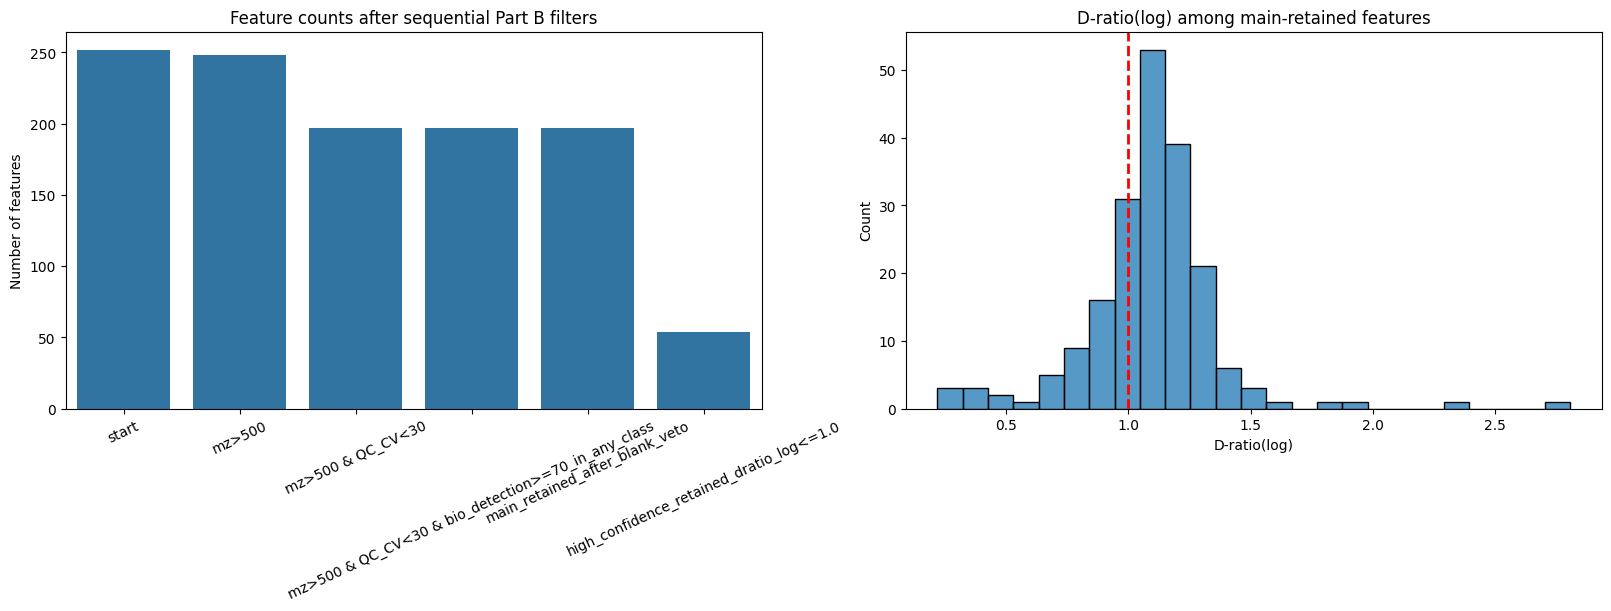

In [11]:
feature_filter_table, feature_filter_summary = build_feature_filter_table(
    technical_biological_metrics=batch1_qc_only_techbio,
    feature_detection_metrics=batch1_feature_detection,
    contamination_metrics=batch1_contamination_metrics,
    blank_carryover_proxy=batch1_blank_carryover_proxy,
    qc_cv_threshold=30.0,
    bio_detection_threshold=0.70,
    mz_threshold=500.0,
    blank_ratio_veto=0.50,
    blank_detection_veto=0.50,
    d_ratio_log_high_conf=1.0,
)

display(feature_filter_summary)

display(
    feature_filter_table[
        [
            "feature",
            "mz",
            "rt",
            "qc_cv_pct",
            "bio_detection_rate_max",
            "blank_detection_rate",
            "blank_to_bio_ratio",
            "blank_dominant_veto",
            "potential_carryover_flag",
            "d_ratio_log",
            "retained_main",
            "retained_high_confidence",
            "exclusion_reason",
        ]
    ].head(30)
)

fig = plot_feature_filtering_summary(feature_filter_summary, feature_filter_table)
plt.show()

The main retained feature set is defined by the assignment-mandated filters plus a conservative contamination veto. D-ratio is then used to identify a stricter high-confidence subset among the already retained features. This gives us both a broad discovery-ready feature space and a more conservative shortlist for stronger evidence.

Among the retained features, many fell into candidate multi-feature families defined by RT/m/z proximity and pairwise correlation. These likely reflect isomeric structure, isotope/adduct relationships, or correlated near-duplicate signals.

We keep these annotations as an interpretability layer rather than collapsing all features automatically. This preserves potentially meaningful isomeric signals while allowing Part C to avoid overweighting highly redundant feature families.

## Part B.8 — Final retained samples and features for downstream discovery

At the end of Part B, we materialize the retained biological samples and the retained feature sets. We keep two feature views:
- a **main retained set** for downstream discriminatory analysis,
- a **high-confidence subset** with favorable D-ratio(log).

The modeling matrix uses the selected transformed representation (`tic_log1p`) and contains only retained biological samples.

In [12]:
partb_outputs = assemble_partb_outputs(
    raw_data_matrix=batch1_dm,
    transformed_data_matrix=batch1_dm_transformed,
    acquisition_list=batch1_acq,
    sample_review_table=bio_sample_review,
    feature_filter_table=feature_filter_table,
)

display(partb_outputs["partb_output_summary"])
display(partb_outputs["retained_sample_manifest"].head(10))
display(partb_outputs["retained_feature_manifest_main"].head(20))
display(partb_outputs["retained_feature_manifest_high"].head(20))
print(partb_outputs["partc_matrix_main"].shape)
print(partb_outputs["partc_matrix_high_conf"].shape)

,artifact,n
0,retained_biological_samples,76
1,retained_main_features,197
2,retained_high_confidence_features,54


,sample,class,order,batch,total_signal_raw,log10_total_signal_plus1,detected_features,detection_rate,zero_fraction,corr_to_class_median,...,corr_to_class_median_robust_z_within_class,pca_distance_to_class_centroid_robust_z_within_class,flag_low_total_signal,flag_low_detected_features,flag_high_zero_fraction,flag_low_corr_to_class_median,flag_high_pca_distance,n_review_flags,recommend_exclude,review_tier
0,20241106-297-Dunn-20,Dunn,15,1,9.524756e+05,5.978854,250,0.992063,0.007937,0.976341,...,-2.629226,0.495443,False,False,False,False,False,0,False,keep
1,20241106-297-Dunn-17,Dunn,18,1,6.855580e+05,5.836045,250,0.992063,0.007937,0.991262,...,0.000000,1.188967,False,False,False,False,False,0,False,keep
2,20241106-297-Dunn-7,Dunn,19,1,8.402055e+05,5.924386,250,0.992063,0.007937,0.993909,...,0.466359,0.372808,False,False,False,False,False,0,False,keep
3,20241106-297-Dunn-1,Dunn,21,1,8.156961e+05,5.911529,250,0.992063,0.007937,0.995090,...,0.674500,0.085936,False,False,False,False,False,0,False,keep
4,20241106-297-Dunn-21,Dunn,24,1,1.034691e+06,6.014811,251,0.996032,0.003968,0.993176,...,0.337201,0.176195,False,False,False,False,False,0,False,keep
5,20241106-297-Dunn-5,Dunn,29,1,6.605454e+05,5.819903,250,0.992063,0.007937,0.992096,...,0.146931,0.551584,False,False,False,False,False,0,False,keep
6,20241106-297-Dunn-4,Dunn,33,1,9.817891e+05,5.992019,249,0.988095,0.011905,0.997283,...,1.060887,-0.537924,False,False,False,False,False,0,False,keep
7,20241106-297-Dunn-23,Dunn,34,1,9.275299e+05,5.967328,250,0.992063,0.007937,0.996398,...,0.905070,-0.653137,False,False,False,False,False,0,False,keep
8,20241106-297-Dunn-11,Dunn,36,1,7.852495e+05,5.895008,251,0.996032,0.003968,0.997842,...,1.159457,-1.152295,False,False,False,False,False,0,False,keep
9,20241106-297-Dunn-26,Dunn,37,1,8.910058e+05,5.949881,250,0.992063,0.007937,0.996326,...,0.892253,-1.000830,False,False,False,False,False,0,False,keep


,feature,qc_mean_intensity,qc_std_intensity,qc_cv_pct,qc_log_sd,qc_detection_rate,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,...,bio_detection_rate_max,passes_mz_500,passes_qc_cv_30,passes_detection_70_any_class,passes_detection_70_all_classes,blank_dominant_veto,potential_carryover_flag,retained_main,retained_high_confidence,exclusion_reason
0,FT-145,1085.001386,173.356550,15.977542,0.155645,0.909091,860.100181,165.600263,19.253602,0.194992,...,1.0,True,True,True,True,False,False,True,True,retained
1,FT-015,1948.204868,335.924066,17.242749,0.179359,0.909091,2066.396647,570.960239,27.630718,0.806941,...,1.0,True,True,True,True,False,False,True,True,retained
2,FT-174,28.534949,6.840222,23.971384,0.248808,0.909091,42.781426,85.144228,199.021480,0.966589,...,1.0,True,True,True,False,False,False,True,True,retained
3,FT-188,84.058692,24.552221,29.208426,0.285823,1.000000,153.373854,282.512535,184.198628,0.591367,...,1.0,True,True,True,True,False,False,True,True,retained
4,FT-028,555.703429,136.732905,24.605374,0.271682,0.909091,639.351551,184.401834,28.842009,0.817646,...,1.0,True,True,True,True,False,False,True,True,retained
5,FT-156,2067.210688,388.604936,18.798516,0.184303,0.909091,1988.401514,464.982020,23.384715,0.431486,...,1.0,True,True,True,True,False,False,True,True,retained
6,FT-217,113.997445,25.211089,22.115486,0.232142,1.000000,109.456430,32.717332,29.890736,0.307383,...,1.0,True,True,True,True,False,False,True,True,retained
7,FT-146,261.609109,47.000978,17.966109,0.175877,0.909091,261.959670,65.711443,25.084565,0.287247,...,1.0,True,True,True,True,False,False,True,True,retained
8,FT-172,73.047712,18.844066,25.796929,0.255762,0.818182,172.061863,224.132424,130.262698,1.511243,...,1.0,True,True,True,False,False,False,True,True,retained
9,FT-089,2103.151188,232.500700,11.054873,0.109448,1.000000,2038.935859,319.775649,15.683458,0.187345,...,1.0,True,True,True,True,False,False,True,True,retained


,feature,qc_mean_intensity,qc_std_intensity,qc_cv_pct,qc_log_sd,qc_detection_rate,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,...,bio_detection_rate_max,passes_mz_500,passes_qc_cv_30,passes_detection_70_any_class,passes_detection_70_all_classes,blank_dominant_veto,potential_carryover_flag,retained_main,retained_high_confidence,exclusion_reason
0,FT-145,1085.001386,173.356550,15.977542,0.155645,0.909091,860.100181,165.600263,19.253602,0.194992,...,1.0,True,True,True,True,False,False,True,True,retained
1,FT-015,1948.204868,335.924066,17.242749,0.179359,0.909091,2066.396647,570.960239,27.630718,0.806941,...,1.0,True,True,True,True,False,False,True,True,retained
2,FT-174,28.534949,6.840222,23.971384,0.248808,0.909091,42.781426,85.144228,199.021480,0.966589,...,1.0,True,True,True,False,False,False,True,True,retained
3,FT-188,84.058692,24.552221,29.208426,0.285823,1.000000,153.373854,282.512535,184.198628,0.591367,...,1.0,True,True,True,True,False,False,True,True,retained
4,FT-028,555.703429,136.732905,24.605374,0.271682,0.909091,639.351551,184.401834,28.842009,0.817646,...,1.0,True,True,True,True,False,False,True,True,retained
5,FT-156,2067.210688,388.604936,18.798516,0.184303,0.909091,1988.401514,464.982020,23.384715,0.431486,...,1.0,True,True,True,True,False,False,True,True,retained
6,FT-217,113.997445,25.211089,22.115486,0.232142,1.000000,109.456430,32.717332,29.890736,0.307383,...,1.0,True,True,True,True,False,False,True,True,retained
7,FT-146,261.609109,47.000978,17.966109,0.175877,0.909091,261.959670,65.711443,25.084565,0.287247,...,1.0,True,True,True,True,False,False,True,True,retained
8,FT-172,73.047712,18.844066,25.796929,0.255762,0.818182,172.061863,224.132424,130.262698,1.511243,...,1.0,True,True,True,False,False,False,True,True,retained
9,FT-089,2103.151188,232.500700,11.054873,0.109448,1.000000,2038.935859,319.775649,15.683458,0.187345,...,1.0,True,True,True,True,False,False,True,True,retained


(76, 198)
(76, 55)


In [13]:
partb_out_dir = project_root / "data" / "processed" / "task1_partb_filtered"
partb_out_dir.mkdir(parents=True, exist_ok=True)

bio_sample_review.to_csv(partb_out_dir / "batch1_biological_sample_review.csv", index=False)
bio_sample_review_summary.to_csv(partb_out_dir / "batch1_biological_sample_review_summary.csv", index=False)

batch1_qc_only_techbio.to_csv(partb_out_dir / "batch1_qc_only_technical_biological_metrics.csv", index=False)
feature_filter_table.to_csv(partb_out_dir / "batch1_feature_filter_table.csv", index=False)
feature_filter_summary.to_csv(partb_out_dir / "batch1_feature_filter_summary.csv", index=False)

partb_outputs["retained_sample_manifest"].to_csv(partb_out_dir / "retained_sample_manifest.csv", index=False)
partb_outputs["retained_feature_manifest_main"].to_csv(partb_out_dir / "retained_feature_manifest_main.csv", index=False)
partb_outputs["retained_feature_manifest_high"].to_csv(partb_out_dir / "retained_feature_manifest_high.csv", index=False)
partb_outputs["partc_matrix_main"].to_csv(partb_out_dir / "partc_matrix_main.csv", index=False)
partb_outputs["partc_matrix_high_conf"].to_csv(partb_out_dir / "partc_matrix_high_conf.csv", index=False)
partb_outputs["partc_sample_metadata"].to_csv(partb_out_dir / "partc_sample_metadata.csv", index=False)
partb_outputs["partb_output_summary"].to_csv(partb_out_dir / "partb_output_summary.csv", index=False)

print(f"Saved Part B filtered outputs to: {partb_out_dir}")

Saved Part B filtered outputs to: C:\Users\zakar\OneDrive\Bureau\ml-internship\data\processed\task1_partb_filtered



Threshold ablation showed that the retained feature count is sensitive to the QC CV cutoff, but much less sensitive to the biological detection threshold once the main QC filter is applied. D-ratio was therefore used as a secondary confidence layer rather than a primary exclusion rule.

The final Part B output is a discovery-ready dataset composed of 76 retained biological samples, 197 main retained features, and a stricter 54-feature high-confidence subset for more conservative downstream analysis.

In [15]:
from task1_finalize import (
    annotate_feature_redundancy,
    plot_redundancy_summary,
    compute_partb_threshold_ablation,
    plot_partb_threshold_ablation,
    build_partc_handoff_tables,
)


The current Part B filtering results are technically coherent and suitable for finalization. The sample review removed only three biological samples, which suggests the scorecard is conservative rather than overly aggressive. These excluded samples are also the most convincing technical outliers, combining low correlation to their class median profile with large PCA displacement.

At the feature level, the QC CV criterion is the main source of filtering, which is appropriate because technical stability is the central requirement in this phase. The detection-support criterion removes no additional features, indicating that once the operational detection threshold was fixed, the retained features already had strong biological support. Likewise, the blank veto has no additional effect, which confirms that contamination is not a dominant driver after thresholding.

The retained main feature set is therefore broad but defensible, while the D-ratio high-confidence subset provides a more conservative shortlist for prioritization.

## Part B.9 — Structural redundancy annotation

Many retained features are likely not fully independent. Some may correspond to putative isomers, isotope/adduct variants, or highly correlated near-duplicate signals. At this stage, we do not collapse them blindly. Instead, we annotate redundancy so that Part C can avoid overweighting clusters of technically related features while still preserving potentially meaningful isomeric structure.

This produces a richer feature decision table rather than a simplified but less interpretable matrix.

,redundancy_cluster_id,cluster_size,representative_feature
0,RG-010,25,FT-076
1,RG-009,24,FT-101
2,RG-014,17,FT-206
3,RG-015,16,FT-066
4,RG-007,14,FT-243
5,RG-018,12,FT-161
6,RG-024,9,FT-031
7,RG-016,8,FT-102
8,RG-017,8,FT-046
9,RG-012,7,FT-040


,feature_a,feature_b,spearman_rho,mz_a,mz_b,rt_a,rt_b,mz_diff,rt_diff,candidate_isomer,candidate_isotope_or_adduct,high_corr_near_duplicate,high_corr_other,relation_type
0,FT-145,FT-146,0.328120,1632.042224,1633.038705,1455.244908,1439.039143,0.996481,16.205765,False,True,False,False,candidate_isotope_or_adduct
1,FT-174,FT-012,0.137400,1210.830470,1210.824056,928.694830,874.606710,0.006415,54.088120,True,False,False,False,candidate_isomer
2,FT-188,FT-186,0.161996,931.123316,931.624305,1102.187969,1102.186769,0.500988,0.001200,False,True,False,False,candidate_isotope_or_adduct
3,FT-188,FT-189,0.113083,931.123316,931.123021,1102.187969,1117.150901,0.000295,14.962932,True,False,False,False,candidate_isomer
4,FT-188,FT-187,0.103732,931.123316,931.624904,1102.187969,1117.118088,0.501588,14.930119,False,True,False,False,candidate_isotope_or_adduct
5,FT-217,FT-245,0.366097,1089.028799,1083.021308,1473.438882,1473.133025,6.007491,0.305857,False,True,False,False,candidate_isotope_or_adduct
6,FT-217,FT-133,0.681176,1089.028799,1088.355496,1473.438882,1455.618809,0.673304,17.820073,False,True,False,False,candidate_isotope_or_adduct
7,FT-217,FT-241,0.362679,1089.028799,1083.347914,1473.438882,1473.378559,5.680885,0.060323,False,True,False,False,candidate_isotope_or_adduct
8,FT-217,FT-244,0.405714,1089.028799,1083.014483,1473.438882,1455.407052,6.014316,18.031829,False,True,False,False,candidate_isotope_or_adduct
9,FT-217,FT-240,0.378100,1089.028799,1083.346664,1473.438882,1455.299982,5.682135,18.138900,False,True,False,False,candidate_isotope_or_adduct


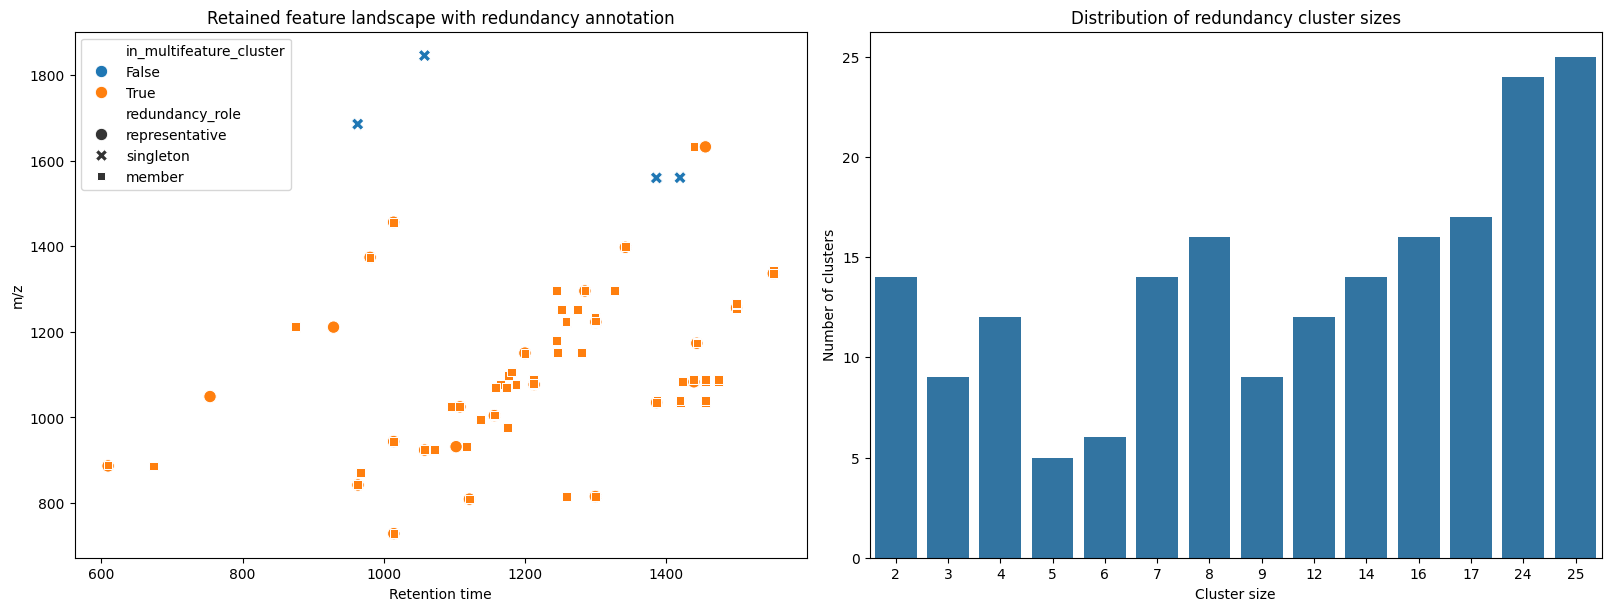

In [16]:
retained_feature_annotated, retained_pairwise_redundancy, retained_cluster_summary = annotate_feature_redundancy(
    modeling_matrix=partb_outputs["partc_matrix_main"],
    retained_feature_manifest=partb_outputs["retained_feature_manifest_main"],
)

display(retained_cluster_summary.head(20))
display(retained_pairwise_redundancy.head(20))

fig = plot_redundancy_summary(retained_feature_annotated)
plt.show()

Redundancy is handled as annotation rather than automatic deletion. Candidate isomers are especially kept as separate features because same-mass peaks at different retention times may still represent biologically meaningful differences. For highly correlated same-family groups, we designate a representative feature so that downstream modeling can avoid giving excessive weight to one structural neighborhood.

In [17]:
redundancy_cols = [
    "feature",
    "redundancy_cluster_id",
    "redundancy_cluster_size",
    "candidate_isomer_neighbor_count",
    "candidate_isotope_or_adduct_neighbor_count",
    "high_corr_near_duplicate_neighbor_count",
    "high_corr_other_neighbor_count",
    "redundancy_representative_flag",
    "redundancy_role",
]

feature_decision_table_final = feature_filter_table.merge(
    retained_feature_annotated[redundancy_cols],
    on="feature",
    how="left",
    validate="one_to_one",
)

feature_decision_table_final["redundancy_cluster_size"] = (
    feature_decision_table_final["redundancy_cluster_size"].fillna(1).astype(int)
)
for col in [
    "candidate_isomer_neighbor_count",
    "candidate_isotope_or_adduct_neighbor_count",
    "high_corr_near_duplicate_neighbor_count",
    "high_corr_other_neighbor_count",
]:
    feature_decision_table_final[col] = feature_decision_table_final[col].fillna(0).astype(int)

feature_decision_table_final["redundancy_representative_flag"] = (
    feature_decision_table_final["redundancy_representative_flag"].fillna(False)
)
feature_decision_table_final["redundancy_role"] = (
    feature_decision_table_final["redundancy_role"].fillna("not_modeled")
)

display(feature_decision_table_final.head(20))

,feature,qc_mean_intensity,qc_std_intensity,qc_cv_pct,qc_log_sd,qc_detection_rate,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,...,retained_high_confidence,exclusion_reason,redundancy_cluster_id,redundancy_cluster_size,candidate_isomer_neighbor_count,candidate_isotope_or_adduct_neighbor_count,high_corr_near_duplicate_neighbor_count,high_corr_other_neighbor_count,redundancy_representative_flag,redundancy_role
0,FT-145,1085.001386,173.356550,15.977542,0.155645,0.909091,860.100181,165.600263,19.253602,0.194992,...,True,retained,RG-001,2,0,1,0,0,True,representative
1,FT-015,1948.204868,335.924066,17.242749,0.179359,0.909091,2066.396647,570.960239,27.630718,0.806941,...,True,retained,RG-002,1,0,0,0,0,True,singleton
2,FT-174,28.534949,6.840222,23.971384,0.248808,0.909091,42.781426,85.144228,199.021480,0.966589,...,True,retained,RG-003,3,1,0,0,0,True,representative
3,FT-188,84.058692,24.552221,29.208426,0.285823,1.000000,153.373854,282.512535,184.198628,0.591367,...,True,retained,RG-004,4,1,2,0,0,False,member
4,FT-028,555.703429,136.732905,24.605374,0.271682,0.909091,639.351551,184.401834,28.842009,0.817646,...,True,retained,RG-005,1,0,0,0,0,True,singleton
5,FT-156,2067.210688,388.604936,18.798516,0.184303,0.909091,1988.401514,464.982020,23.384715,0.431486,...,True,retained,RG-006,1,0,0,0,0,True,singleton
6,FT-217,113.997445,25.211089,22.115486,0.232142,1.000000,109.456430,32.717332,29.890736,0.307383,...,True,retained,RG-007,14,1,5,0,0,False,member
7,FT-146,261.609109,47.000978,17.966109,0.175877,0.909091,261.959670,65.711443,25.084565,0.287247,...,True,retained,RG-001,2,0,1,0,0,False,member
8,FT-172,73.047712,18.844066,25.796929,0.255762,0.818182,172.061863,224.132424,130.262698,1.511243,...,True,retained,RG-008,5,1,0,0,0,False,member
9,FT-089,2103.151188,232.500700,11.054873,0.109448,1.000000,2038.935859,319.775649,15.683458,0.187345,...,True,retained,RG-009,24,0,9,0,0,False,member


## Part B.10 — Threshold-ablation analysis

The assignment provides target criteria such as QC CV < 30% and detection support >= 70%, but it is still useful to show that these choices are reasonable rather than arbitrary. We therefore evaluate how the retained feature count changes under stricter and looser QC, detection, and D-ratio thresholds.

This gives a compact sensitivity analysis and helps justify the final retained set.

,criterion_type,threshold,n_features
0,qc_cv_threshold,20.00,135
1,qc_cv_threshold,30.00,197
2,qc_cv_threshold,40.00,229
3,bio_detection_threshold,0.50,197
4,bio_detection_threshold,0.70,197
5,bio_detection_threshold,0.90,197
6,d_ratio_log_threshold,0.75,17
7,d_ratio_log_threshold,1.00,54
8,d_ratio_log_threshold,1.25,162


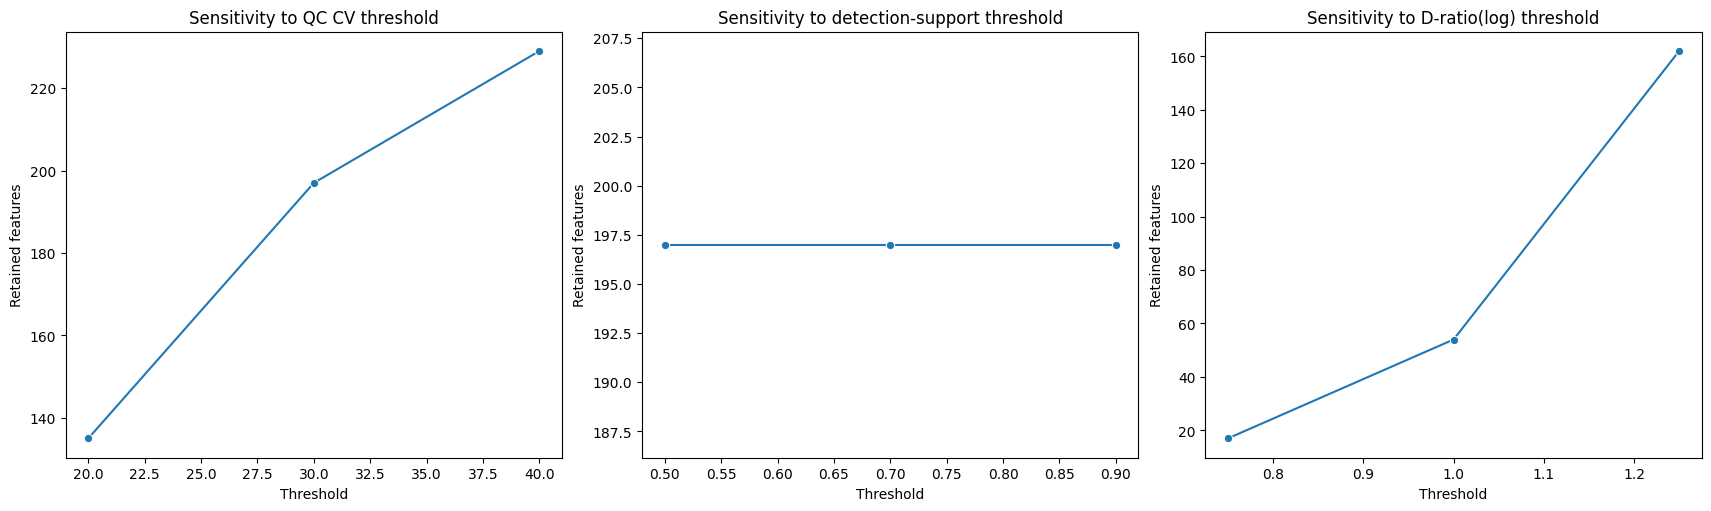

In [18]:
threshold_ablation_table = compute_partb_threshold_ablation(
    feature_filter_table=feature_decision_table_final,
    qc_cv_thresholds=(20.0, 30.0, 40.0),
    bio_detection_thresholds=(0.50, 0.70, 0.90),
    d_ratio_log_thresholds=(0.75, 1.00, 1.25),
)

display(threshold_ablation_table)

fig = plot_partb_threshold_ablation(threshold_ablation_table)
plt.show()

This ablation analysis shows whether the final retained count is robust to moderate threshold changes. In our case, the QC CV cutoff is the main driver of feature removal, while the detection-support rule has little additional effect because the retained features already have strong biological support. D-ratio then acts as a secondary prioritization layer rather than the main gate.

## Part B.11 — Discovery-ready handoff to Part C

Part B ends with two outputs:

1. A strict modeling matrix for discriminatory analysis, containing retained biological samples, retained features, and the selected transformed intensities.
2. A full feature decision table, containing filtering metrics, contamination flags, D-ratio values, redundancy annotation, and the final retain/exclude status.

This keeps the downstream analysis reproducible while preserving enough annotation for interpretation.

In [19]:
partc_handoff = build_partc_handoff_tables(
    sample_review_table=bio_sample_review,
    feature_decision_table=feature_decision_table_final,
    selected_transform=SELECTED_TRANSFORM,
    detection_threshold=DETECTION_THRESHOLD,
)

display(partc_handoff["handoff_sample_summary"])
display(partc_handoff["handoff_feature_summary"])
display(partc_handoff["handoff_config_summary"])
display(partc_handoff["handoff_caveat_summary"])

,class,n_total,n_retained,n_excluded,n_minor_or_worse,n_review_or_worse
0,Dunn,27,26,1,3,1
1,French,26,26,0,3,0
2,LMU,26,24,2,4,2


,metric,value
0,n_features_total,252
1,n_features_main_retained,197
2,n_features_high_confidence,54
3,n_main_features_with_potential_carryover_flag,3
4,n_main_features_in_multifeature_clusters,193
5,n_main_representative_features,30


,setting,value
0,selected_transform,tic_log1p
1,operational_detection_threshold,10.0
2,qc_cv_threshold,30.0
3,bio_detection_threshold_any_class,0.7
4,mz_threshold,500.0


,caveat,n
0,excluded_biological_samples,3
1,main_features_with_carryover_warning,3
2,main_features_in_multifeature_redundancy_clusters,193


The final Part B dataset is technically filtered, sample-reviewed, and annotated for structural redundancy. The main retained feature set is intentionally broad enough for discovery, while the high-confidence subset provides a more conservative layer for prioritization. Any remaining technical caveats are explicitly tracked rather than hidden.

In [20]:
partb_final_dir = project_root / "data" / "processed" / "task1_partb_final"
partb_final_dir.mkdir(parents=True, exist_ok=True)

retained_feature_annotated.to_csv(partb_final_dir / "retained_feature_manifest_main_annotated.csv", index=False)
retained_pairwise_redundancy.to_csv(partb_final_dir / "retained_feature_pairwise_redundancy.csv", index=False)
retained_cluster_summary.to_csv(partb_final_dir / "retained_feature_redundancy_clusters.csv", index=False)

feature_decision_table_final.to_csv(partb_final_dir / "feature_decision_table_final.csv", index=False)
threshold_ablation_table.to_csv(partb_final_dir / "threshold_ablation_table.csv", index=False)

for name, df in partc_handoff.items():
    df.to_csv(partb_final_dir / f"{name}.csv", index=False)

# Save the actual discovery-ready matrices too
partb_outputs["retained_sample_manifest"].to_csv(partb_final_dir / "retained_sample_manifest.csv", index=False)
partb_outputs["retained_feature_manifest_main"].to_csv(partb_final_dir / "retained_feature_manifest_main.csv", index=False)
partb_outputs["retained_feature_manifest_high"].to_csv(partb_final_dir / "retained_feature_manifest_high.csv", index=False)
partb_outputs["partc_matrix_main"].to_csv(partb_final_dir / "partc_matrix_main.csv", index=False)
partb_outputs["partc_matrix_high_conf"].to_csv(partb_final_dir / "partc_matrix_high_conf.csv", index=False)
partb_outputs["partc_sample_metadata"].to_csv(partb_final_dir / "partc_sample_metadata.csv", index=False)

print(f"Saved final Part B outputs to: {partb_final_dir}")

Saved final Part B outputs to: C:\Users\zakar\OneDrive\Bureau\ml-internship\data\processed\task1_partb_final


## Part B conclusion

Part B produced a batch-1 discovery-ready dataset by combining technical filtering, sample review, contamination control, and structural annotation.

The main decisions were:
- restrict processing to batch 1,
- use detection threshold `> 10`,
- use **QC-only** as the primary technical stability reference,
- select `tic_log1p` as the operational transformed view,
- exclude only 3 biological samples with strong multi-metric evidence of technical abnormality,
- retain 197 main features after applying the required Part B criteria,
- define a stricter 54-feature high-confidence subset using D-ratio,
- carry forward redundancy annotations so that Part C can distinguish broad signal coverage from correlated feature families.

Overall, the processed dataset appears technically coherent and suitable for discriminatory analysis, while preserving an audit trail for every sample and feature decision.